In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

This notebook, intended not as a referance meteral, but as my own notes, takes the following steps toward pricing a swaption from first principles:
1. Extract forward rates from UST yeild curve (UST is eaysier to acsess than SOFR).
2. Compute discount factors allong forward curve.
3. Demonstrate valuation of forward cash flows. (not complete)
4. Implement one factor Hull-White model for forward rate paths. (not complete)
5. Run MC simulation on swap or swaption cash flows. (not complete)

### 1. Extract forward rates from UST yeild curve.
First, we must be able to extract the forward rates curve from real data. Since I have best acsess to tresury bonds at the 1,2,3,4,6 month and 1,2,3,5 year marks, I will need to take that specific form as input. I will convert this data into an array representing the current forward rate each quarter for five years.

To solve for forward rates in an arb free market, we can enforce equality between investing for some peorid $t_2$ at a known spot rate of $r_2$ and investing for some shorter time $t_1$ at spot rate $r_1$, then reinvesting from $t_1$ to $t_2$ at the unknown forward rate $f$:

$$S_2=S_0e^{r_2t_2}\overset{!}{=}S_{1,f}=S_1e^{f(t_2-t_1)}=S_0e^{r_1t_1}e^{f(t_2-t_1)}$$
$$\rightarrow r_2t_2\overset{!}{=}r_1t_1+f(t_2-t_1)$$
$$\rightarrow f=\frac{r_2t_2-r_1t_1}{t_2-t_1}$$

This equations allows us to solve for the forward rate between any two, known points (r,t). However, we still must interpolate results in reagons where we do not know one or both of the end points. The simplest scheme is to assume the rate is constant during that peorid, i.e. $f_{t \rightarrow T_2}=f_{T_1 \rightarrow T_2}$ for any known forward rate $f_{T_1 \rightarrow T_2}$ over time $T_1<t<T_2$.

Tresury data is from: https://www.cnbc.com/markets/bonds/ as of Jul 17, 2026. Rates must be converted from BEY to EAY using $EAY=(1+\frac{BEY}{2})^2-1$, then to continuously compounding form using $e^{r_{CC}}=1+EAY \rightarrow r_{CC}=\ln({1+EAY})$.

In [42]:
UST_spot_BEY = np.array([3.803, 3.927, 4.004, 4.183, 4.218, 4.28])/100
UST_days     = np.array([90,    180,   360,   360*2, 360*3, 360*5])
UST_spot_EAY = (1+UST_spot_BEY/2)**2-1
UST_spot_CC  = np.log(1+UST_spot_EAY)
print(UST_spot_CC)

[0.03767295 0.03888944 0.03964447 0.04139857 0.04174137 0.04234847]


[]

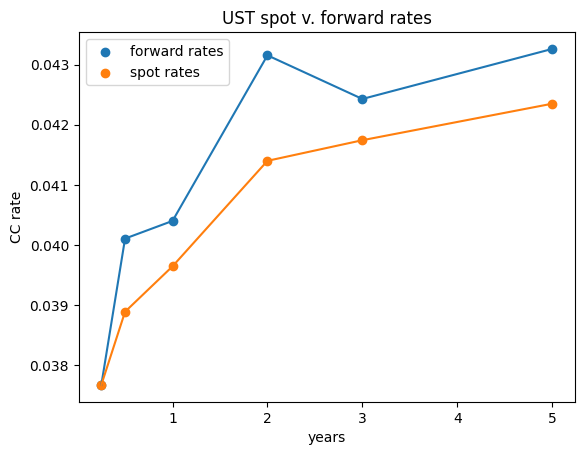

In [43]:
f = lambda r1,t1, r2,t2: (r2*t2-r1*t1)/(t2-t1)

#from this point on, we can assume all rates are CC annual
UST_forward = np.zeros_like(UST_spot_CC)

for i in range(len(UST_spot_CC)):
    if i == 0: #since we get the first forward for free
        UST_forward[i] = UST_spot_CC[i]
    else:
        UST_forward[i] = f(UST_spot_CC[i-1], UST_days[i-1], UST_spot_CC[i], UST_days[i])

plt.scatter(UST_days/360, UST_forward, label='forward rates')
plt.plot(UST_days/360, UST_forward)
plt.scatter(UST_days/360, UST_spot_CC, label='spot rates')
plt.plot(UST_days/360, UST_spot_CC)
plt.title('UST spot v. forward rates')
plt.xlabel('years')
plt.ylabel('CC rate')
plt.legend()
plt.plot()

[]

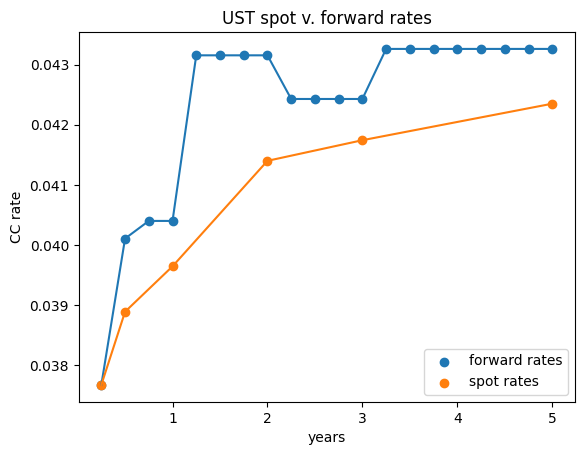

In [44]:
days = np.linspace(90, 5*4*90, 5*4)
buckets = np.digitize(days, UST_days, right=True)
UST_forwards = np.array([UST_forward[i] for i in buckets])

plt.scatter(days/360, UST_forwards, label='forward rates')
plt.plot(days/360, UST_forwards)
plt.scatter(UST_days/360, UST_spot_CC, label='spot rates')
plt.plot(UST_days/360, UST_spot_CC)
plt.title('UST spot v. forward rates')
plt.xlabel('years')
plt.ylabel('CC rate')
plt.legend()
plt.plot()

### 2. Compute discount factors allong forward curve.
We must now construct the discount factors (DF) ascocated with any rates curve. Rates curves will be expressed as an array with each position being the quarterly rate (approxamated as 90 days) for a peorid of 5 years. For continuously compounding rates: $DF(t)=e^{-r(t)*t}$ or for descretly compounding rates: $DF(t)=\frac{1}{(1+r(t))^t}$. For now, we will consider a simplified calendar (exactly 90 days per quarter), and continuously compounding rates.

To properly compute the DF *allong* the forward curve, we must itterate in the following way: $DF_{n}=DF_{n-1}e^{-r_n*t_n}$, where $r_n$ is the rate from $n-1\rightarrow n$ and $t_n$ is the (verrible) time step on the same domain.

In [45]:
#due to the need to referance the prior DF, this must be itterative, not vectorized
def rateToDF(forwards, days):
  df = 1.0
  dfs = np.zeros_like(forwards)
  for i, r in enumerate(forwards):
    df *= np.exp(-r * days[i]/360)
    dfs[i] = df
  return dfs

In [46]:
#sanity check: zero rates
zero_curve_5yr = np.zeros(4*5)
days = np.ones(4*5)*90
print('in a zero rate world, the rates curve looks like: ', zero_curve_5yr)
print('giving discount factors of: ', rateToDF(zero_curve_5yr, days))

in a zero rate world, the rates curve looks like:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
giving discount factors of:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Ok, now we are convinced that we can properly solve for the DF, we will apply it to the real rates curve from the above section.

[]

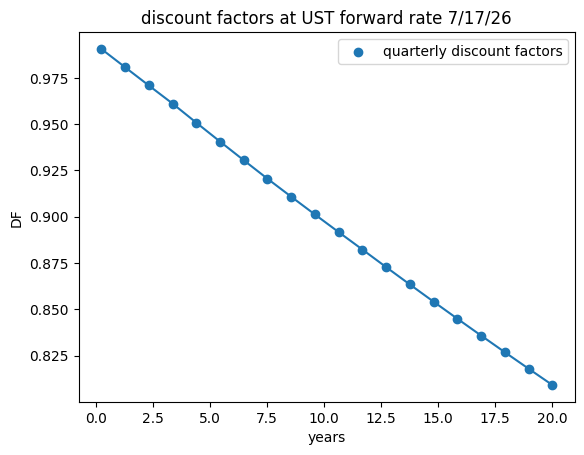

In [47]:
DAYS = np.linspace(90, 4*5*360, 4*5)

plt.scatter(DAYS/360, rateToDF(UST_forwards, days), label='quarterly discount factors')
plt.plot(DAYS/360, rateToDF(UST_forwards, days))
plt.title('discount factors at UST forward rate 7/17/26')
plt.xlabel('years')
plt.ylabel('DF')
plt.legend()
plt.plot()

These points are equivlent to the fair-market-price of a zero coupon bond.

We can cross chek the forward rates against the spot curve by looking at the terminal point, which should be in agreement. (i.e. Investing at spot now for 5 years should match investing at all quarterly forward rates between now and 5 years from now, since the forward curve is, by construction, arb free.)

In [48]:
#PV of moeny 5 years from now at spot
PV_5_spot = np.exp(-UST_spot_CC[-1]*5) #e^r_spot*t
print(PV_5_spot)

0.809173152301617


In [49]:
#PV of moeny 5 years from now, following forward curve
PV_5_FWD = rateToDF(UST_forwards, days)[-1]
print(PV_5_FWD)

0.809173152301617


In [50]:
print(np.isclose(PV_5_spot, PV_5_FWD)) #check that they are the same (within descrete error)

True


Since these match, is there some reason we could not come up with the 5 year DF directly from the spot curve?

Answer: yes, this is done throught a bootstrapping method.

### 3. Demonstrate valuation of forward cash flows.

Having already computed the DFs, valueing forward cash flows is a matter of multiplying by the respective DF (allined in time) and summing. We can try a few kinds of cash flows to make sure the method is sound. First, we can construct something approxamating a bond with quarterly payments and the principal returned after 5 years, then we can construct the fixed leg of a swap with quarterly payments. 

In [51]:
#lets construct a bond which pays $1 every quarter, and $101 after 5 years
bond = np.ones_like(UST_forwards)
bond[-1] += 100
print(bond)

[  1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
   1.   1.   1.   1.   1. 101.]


In [52]:
#now, for PV of this bond, we just multiply UST DFs and sum (equivlent to a vector inner product, so I can use dot)
UST_DFs = rateToDF(UST_forwards, days)
price = bond.dot(UST_DFs)
print('The fair-market-price of the above bond is $', np.round(price, 3), 'based on current UST forward rates.')

The fair-market-price of the above bond is $ 98.874 based on current UST forward rates.


In [53]:
fixed_leg_swap_quartly = lambda notional, r, years: notional*np.ones(years*4)*r/4
fiveper_fiveyr_fixed = fixed_leg_swap_quartly(100, 0.05, 5)
price = fiveper_fiveyr_fixed.dot(UST_DFs)
print('The fixed leg of a swap with the following quartery cash flows: ', fiveper_fiveyr_fixed)
print('has a PV of $', np.round(price,3), 'based on current UST forward rates.')

The fixed leg of a swap with the following quartery cash flows:  [1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25 1.25
 1.25 1.25 1.25 1.25 1.25 1.25]
has a PV of $ 22.446 based on current UST forward rates.


#### Detour; par coupon swap rate.

Now that we can both construct forward DFs, and value the fixed leg of a swap, we can determin the par coupon. To do this, we must find the fixed rate at which the floating leg (at UST forwards) and fixed swap leg have the same PV.

For a $1 notional, the future interest payment is the future value minus the principal:

$$interest = 1-S_1 = 1-e^{rt}$$

which has a present value discounted by the forward rate:

$$PV_{interest}=e^{-ft}(1-e^{rt})=e^{-ft}-e^{(r-f)t}$$

For the floating leg of the swap, valued at today's forward rates, the floating rate is, by construction, the forward rate $f$. However, it is worth noting that this cannot also be true for the fixed leg where $r$ is a single, fixed value for the duration of the swap. So, we can proceed using $f=r$ for the floating leg, but the value of the fixed leg must be computed as it is above with the actual CF discounted at each DF allong the way.

$$r=f: PV_{interest}=e^{-rt}-e^{(r-r)t}=e^{-rt}-1=DF-1$$

So, we can now see that the PV of the floating leg based on today's future rates is path independent because $r$ and $f$ are nessarially the same (they conspire to cancel), but the fixed leg is very much path dependent.

In [54]:
#vlaue of floating leg
1 - UST_DFs[-1]

0.19082684769838298

We can solve for the par coupon rate by making the vlaue each leg of the swap equal, and solving for the fixed coupon:

$$c \sum_{i=1}^n{DF_i} = 1 - DF_n \rightarrow c=\frac{1 - DF_n}{\sum_{i=1}^n{DF_i}}$$

In [69]:
par_coupon = (1-UST_DFs[-1])/np.sum(UST_DFs) * 4
print('par coupon: ', np.round(par_coupon,5))

par coupon:  0.04251


We can confirm that this par coupon indeed gives us the same PV for both legs of the swap.

In [71]:
floating_PV = 1-UST_DFs[-1]
fixed_PV = np.sum(par_coupon/4 * UST_DFs)

print(np.isclose(floating_PV, fixed_PV))

True
